# OT-2: Race 2 Space Test Campaign Data Processing

In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import yaml

> Author: Elias Aoubala

> Date: 10/07/2026

## 1 - Background

This document contains some of the data processing conducted for the R2S-26 text campaign performed. 

## 2 - H5 File Loading

Here, we can load in the HDF5 File in first for the last test we conducted.

In [3]:
test_data = h5py.File("data/20260701-111.h5")

We can extract the pressures:

In [4]:
PTX101 = np.array(test_data["groups"]["experiment"]["PTX101"]["data"])
PTX102 = np.array(test_data["groups"]["experiment"]["PTX102"]["data"])
PTX103 = np.array(test_data["groups"]["experiment"]["PTX103"]["data"])
PTX104 = np.array(test_data["groups"]["experiment"]["PTX104"]["data"])
PTX105 = np.array(test_data["groups"]["experiment"]["PTX105"]["data"])
time_pt = np.array(test_data["groups"]["experiment"]["PTX105"]["time"])

And the gas generator temperatures

In [5]:
TCX101 = np.array(test_data["groups"]["experiment"]["TCX101"]["data"])
TCX102 = np.array(test_data["groups"]["experiment"]["TCX102"]["data"])
time_tc = np.array(test_data["groups"]["experiment"]["TCX102"]["time"])

In [6]:
m_dot_fu = np.array(test_data["groups"]["mdot"]["M730"]["data"])
m_dot_ox = np.array(test_data["groups"]["mdot"]["M850"]["data"])
time_m_dot = np.array(test_data["groups"]["mdot"]["M850"]["time"])

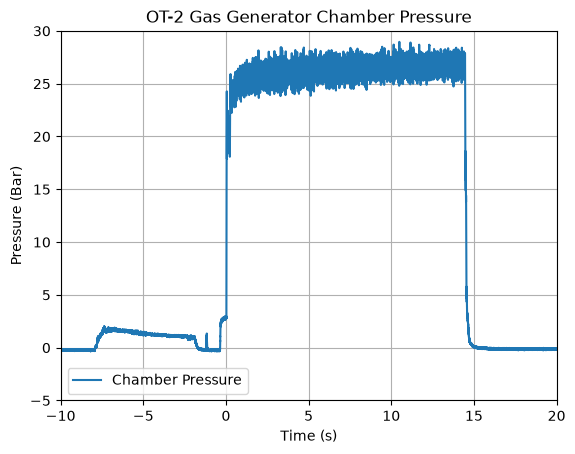

In [16]:
# plt.plot(time_pt, PTX101, label="Pump Inlet Pressure")
# plt.plot(time_pt, PTX102, label="PTX102")
plt.plot(time_pt, PTX103, label="Chamber Pressure")
# plt.plot(time_pt, PTX105, label="PTX105")
# plt.plot(time_pt, PTX104, label="Pump Delivery Pressure")

plt.grid()
plt.xlabel(f"Time (s)")
plt.ylabel(f"Pressure (Bar)")
plt.title(f"OT-2 Gas Generator Chamber Pressure")
plt.xlim((-10,20))
plt.ylim((-5,30))
plt.legend()

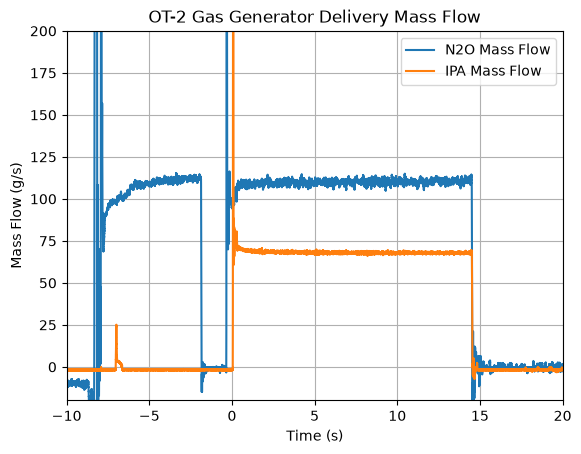

In [8]:
plt.plot(time_m_dot, m_dot_ox*1e3, label="N2O Mass Flow")
plt.plot(time_m_dot, m_dot_fu*1e3, label="IPA Mass Flow")

plt.grid()
plt.xlabel(f"Time (s)")
plt.ylabel(f"Mass Flow (g/s)")
plt.title(f"OT-2 Gas Generator Delivery Mass Flow")
plt.xlim((-10,20))
plt.ylim((-20,200))
plt.legend()

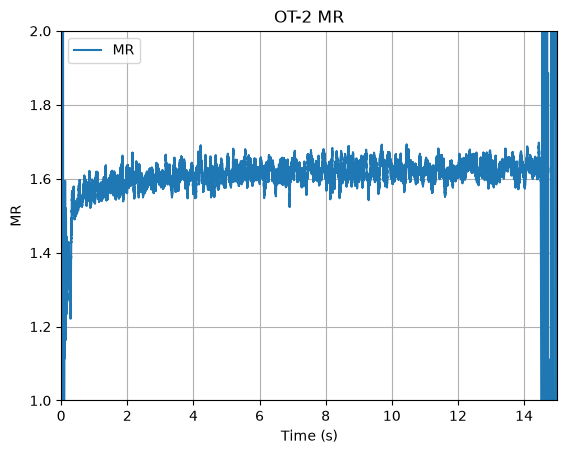

In [57]:
plt.plot(time_m_dot, m_dot_ox/m_dot_fu, label="MR")
# plt.plot(time_m_dot, m_dot_fu*1e3, label="IPA Mass Flow")
plt.grid()
plt.xlabel(f"Time (s)")
plt.ylabel(f"MR")
plt.title(f"OT-2 MR")
plt.xlim((0,15))
plt.ylim((1,2))
plt.legend()

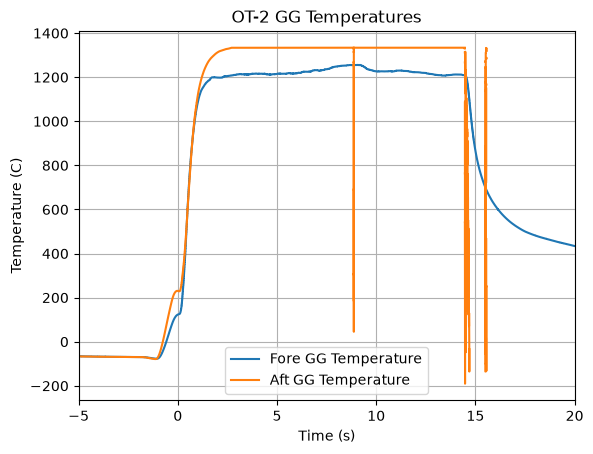

In [91]:
plt.plot(time_tc, TCX101, label="Fore GG Temperature")
plt.plot(time_tc, TCX102, label="Aft GG Temperature")
plt.grid()
plt.xlabel(f"Time (s)")
plt.ylabel(f"Temperature (C)")
plt.title(f"OT-2 GG Temperatures")
plt.xlim((-5,20))
# plt.ylim((0,1400))
plt.legend()

## 3 - Video Processing

In [110]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import spectrogram
import tempfile
import os


def mp4_to_spectrogram(mp4_file, output_png="spectrogram.png"):
    # Create temporary WAV
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp:
        wav_file = tmp.name

    try:
        # Extract audio with ffmpeg
        subprocess.run([
            "ffmpeg",
            "-y",
            "-i", mp4_file,
            "-vn",
            "-ac", "1",        # mono
            "-ar", "44100",    # sample rate
            wav_file
        ], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

        # Read WAV
        sample_rate, audio = wavfile.read(wav_file)

        # Convert to float if needed
        if audio.dtype != np.float32 and audio.dtype != np.float64:
            audio = audio.astype(np.float32)
            audio /= np.iinfo(np.int16).max

        # Compute spectrogram
        f, t, Sxx = spectrogram(
            audio,
            fs=sample_rate,
            window="hann",
            nperseg=2048,
            noverlap=1536,
            scaling="density",
            mode="magnitude"
        )

        # Convert to dB
        Sxx_db = 20 * np.log10(Sxx + 1e-10)

        # Plot
        plt.figure(figsize=(12, 6))
        plt.pcolormesh(t, f, Sxx_db, shading="gouraud", cmap="magma")
        plt.ylabel("Frequency (Hz)")
        plt.xlabel("Time (s)")
        plt.ylim(bottom=10**3)
        plt.colorbar(label="Magnitude (dB)")
        plt.tight_layout()
        plt.xlim(13,30)
        plt.ylim(15000,20000)
        plt.show()

        print(f"Saved to {output_png}")

    finally:
        os.remove(wav_file)

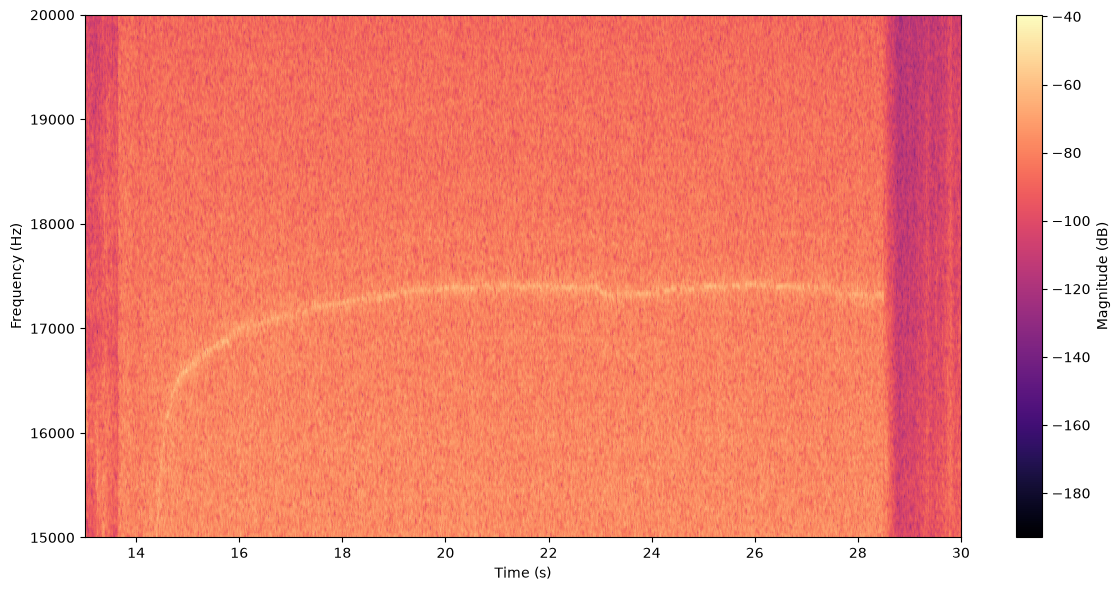

Saved to spectrogram.png


In [111]:
mp4_to_spectrogram("videos/20260701-111_Canon_700D.mp4")